In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('churn.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.shape

(10000, 14)

In [9]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [10]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

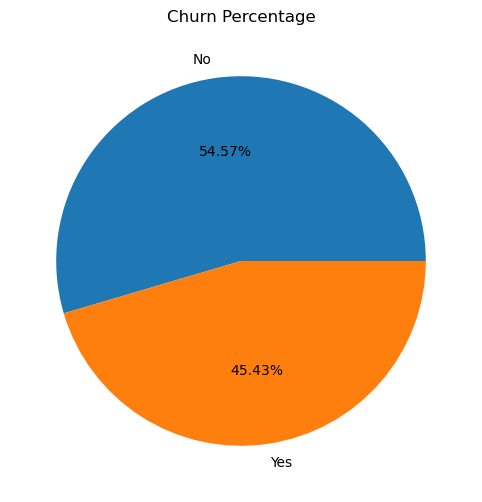

In [13]:
plt.figure(figsize=(10,6))
plt.pie(df['Gender'].value_counts(),labels=['No','Yes'],autopct='%1.2f%%')
plt.title('Churn Percentage')
plt.show()

In [14]:
df.rename(columns={'Exited':'Churn'}, inplace=True)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Churn            10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [16]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


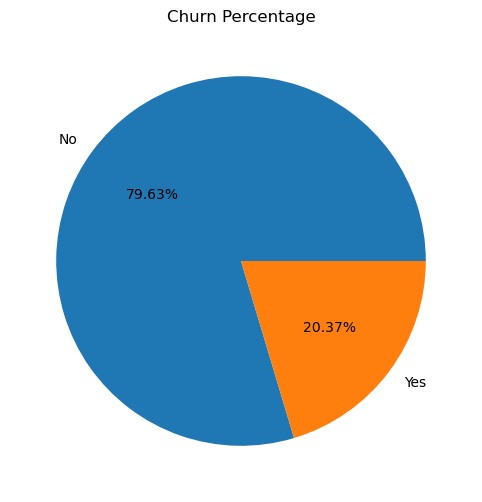

In [17]:
plt.figure(figsize=(10,6))
plt.pie(df['Churn'].value_counts(),labels=['No','Yes'],autopct='%1.2f%%')
plt.title('Churn Percentage')
plt.show()

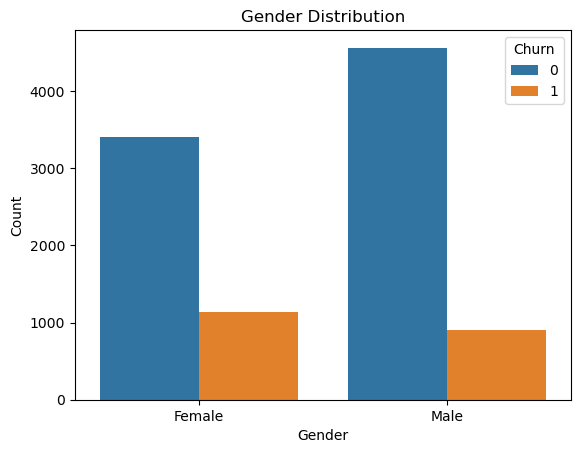

In [18]:
sns.countplot(x = 'Gender', data = df, hue = 'Churn')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

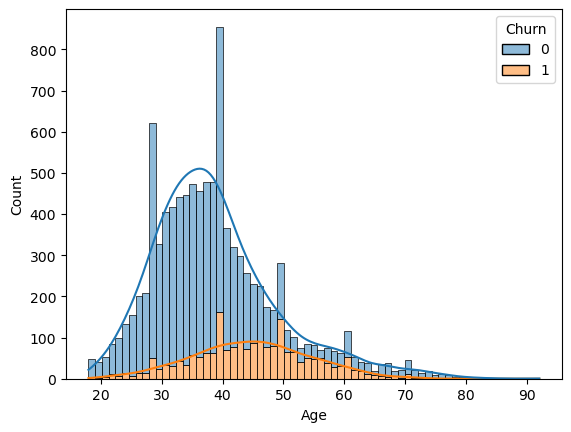

In [19]:
# age distribution
sns.histplot(data=df, x='Age', hue='Churn',multiple='stack',kde=True)

<Axes: xlabel='Churn', ylabel='CreditScore'>

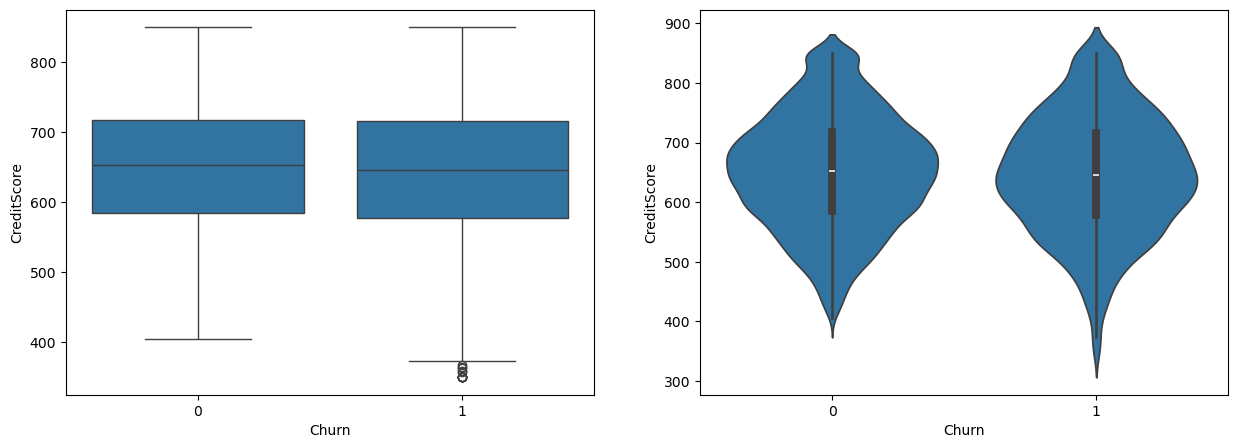

In [20]:
fig,ax=plt.subplots(1,2, figsize=(15,5))
sns.boxplot(x='Churn',y='CreditScore',data=df,ax=ax[0])
sns.violinplot(x='Churn',y='CreditScore',data=df,ax=ax[1])

Text(0, 0.5, 'count')

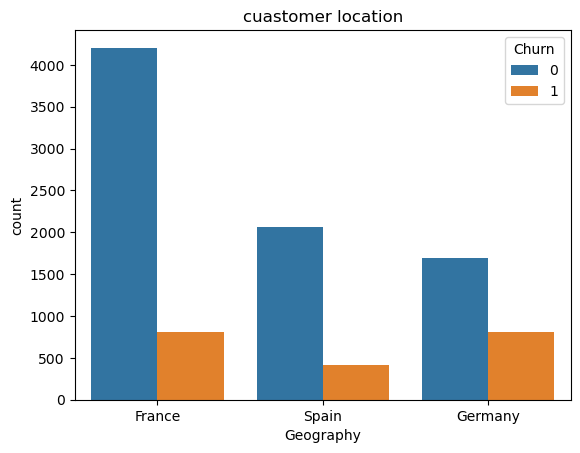

In [21]:
# customer location
sns.countplot(data=df,hue='Churn', x= 'Geography')
plt.title('cuastomer location')
plt.xlabel('Geography')
plt.ylabel('count')

Text(0, 0.5, 'count')

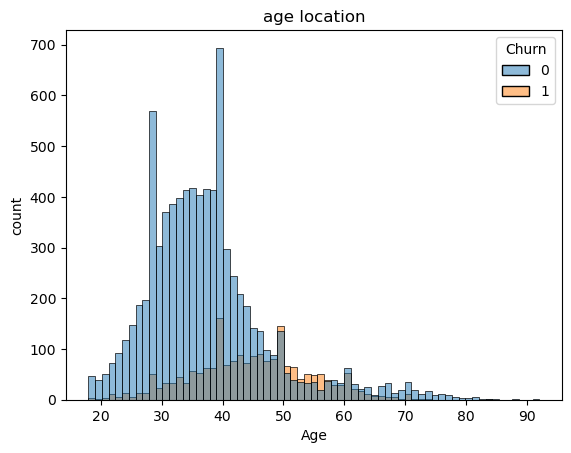

In [22]:
sns.histplot(data=df,hue='Churn', x= 'Age')
plt.title('age location')
plt.xlabel('Age')
plt.ylabel('count')

<Axes: xlabel='Tenure', ylabel='count'>

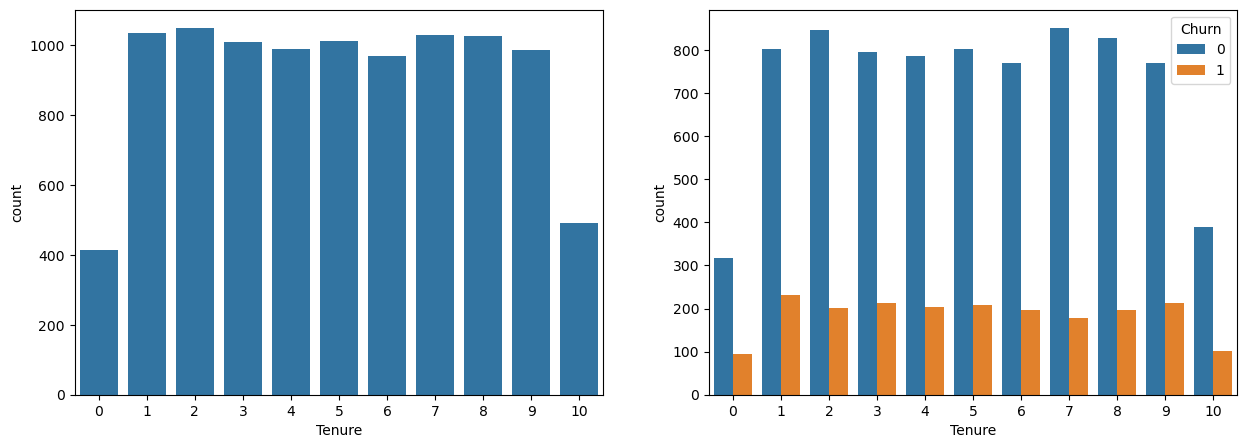

In [23]:
# tenure
fig,ax=plt.subplots(1,2,figsize=(15,5))
sns.countplot(x='Tenure' ,data=df,ax=ax[0])
sns.countplot(x='Tenure',hue='Churn',data=df,ax=ax[1])

<Axes: xlabel='NumOfProducts', ylabel='count'>

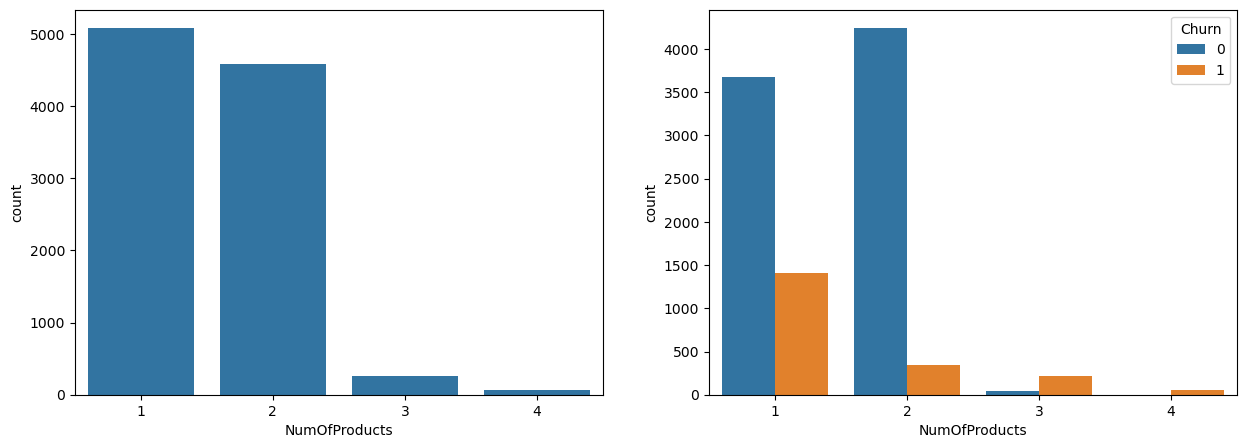

In [24]:
# num of products
fig,ax=plt.subplots(1,2,figsize=(15,5))
sns.countplot(x='NumOfProducts' ,data=df,ax=ax[0])
sns.countplot(x='NumOfProducts',hue='Churn',data=df,ax=ax[1])

<Axes: xlabel='Balance', ylabel='Count'>

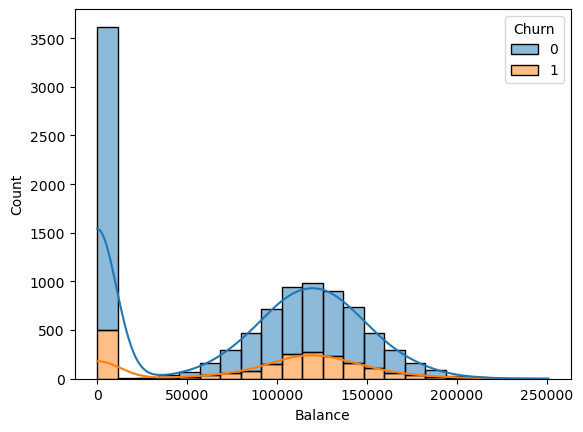

In [25]:
# bank balance
sns.histplot(data=df,hue='Churn',x='Balance',multiple='stack',kde=True)

<Axes: xlabel='NumOfProducts', ylabel='count'>

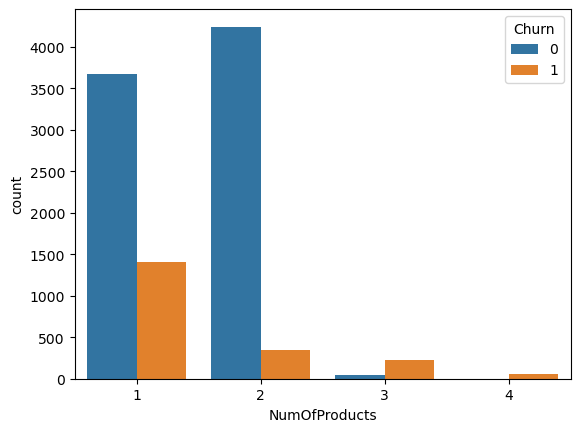

In [26]:
# number of proudts purchased
sns.countplot(x='NumOfProducts',hue='Churn',data=df)

<Axes: xlabel='HasCrCard', ylabel='count'>

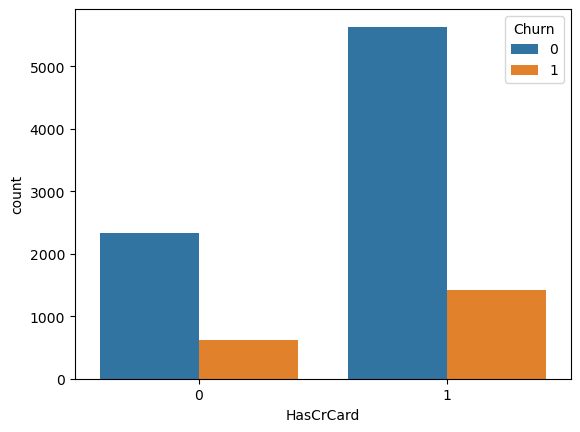

In [27]:
# customer with without credit card
sns.countplot(x=df['HasCrCard'],hue=df['Churn'])

<Axes: xlabel='IsActiveMember', ylabel='count'>

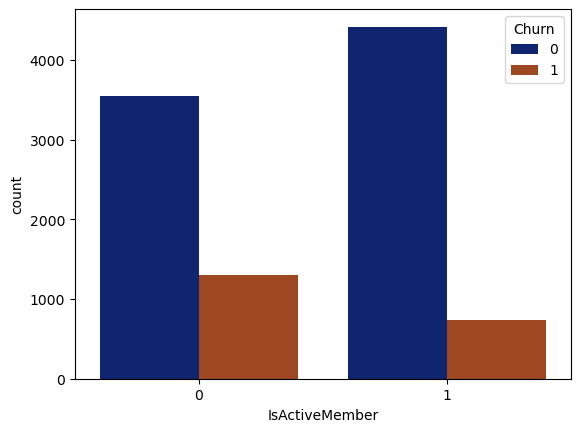

In [28]:
# is active numbers
sns.countplot(x='IsActiveMember',hue='Churn',data=df,palette='dark')

<Axes: xlabel='EstimatedSalary', ylabel='Count'>

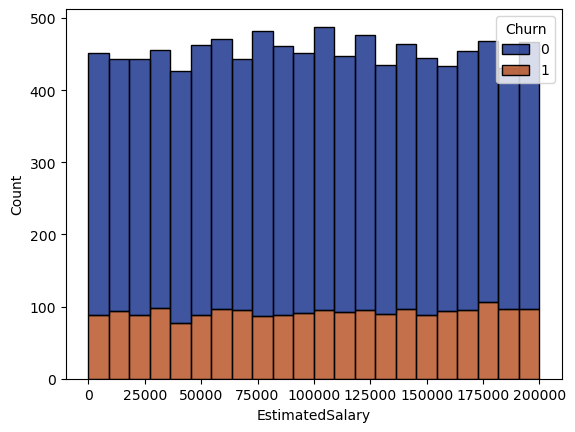

In [29]:
# estimated salary 
sns.histplot(data=df,x='EstimatedSalary',hue='Churn',multiple='stack',palette='dark')

In [30]:
# data preprocessing 2
# laabel encoding 
shiva=['Geography','Gender']
from sklearn .preprocessing import  LabelEncoder
le=LabelEncoder()
for i in shiva:
    le.fit(df[i].unique())
    df[i]=le.transform( df[i])
    print(i,df[i].unique())

Geography [0 2 1]
Gender [0 1]


In [31]:
# normalization with continous vRIBALES
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['CreditScore','Balance','EstimatedSalary']] = scaler.fit_transform(df[['CreditScore','Balance','EstimatedSalary']])


In [32]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
0,1,15634602,Hargrave,-0.326221,0,0,42,2,-1.225848,1,1,1,0.021886,1
1,2,15647311,Hill,-0.440036,2,0,41,1,0.117350,1,0,1,0.216534,0
2,3,15619304,Onio,-1.536794,0,0,42,8,1.333053,3,1,0,0.240687,1
3,4,15701354,Boni,0.501521,0,0,39,1,-1.225848,2,0,0,-0.108918,0
4,5,15737888,Mitchell,2.063884,2,0,43,2,0.785728,1,1,1,-0.365276,0


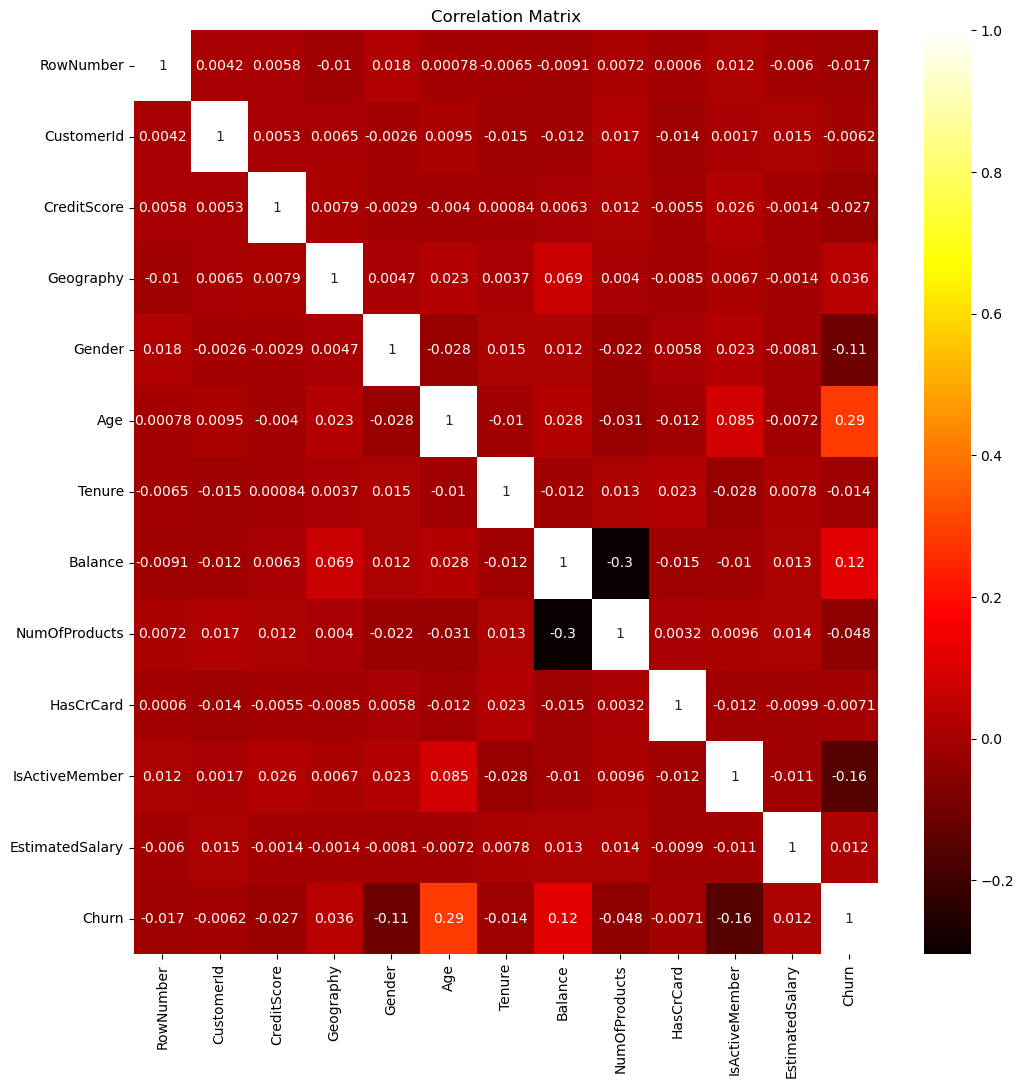

In [33]:
# correlation matrix heatmap
# First, select only numeric columns from the dataframe
numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12,12))
sns.heatmap(numeric_df.corr(), annot=True, cmap='hot')
plt.title('Correlation Matrix')
plt.show()



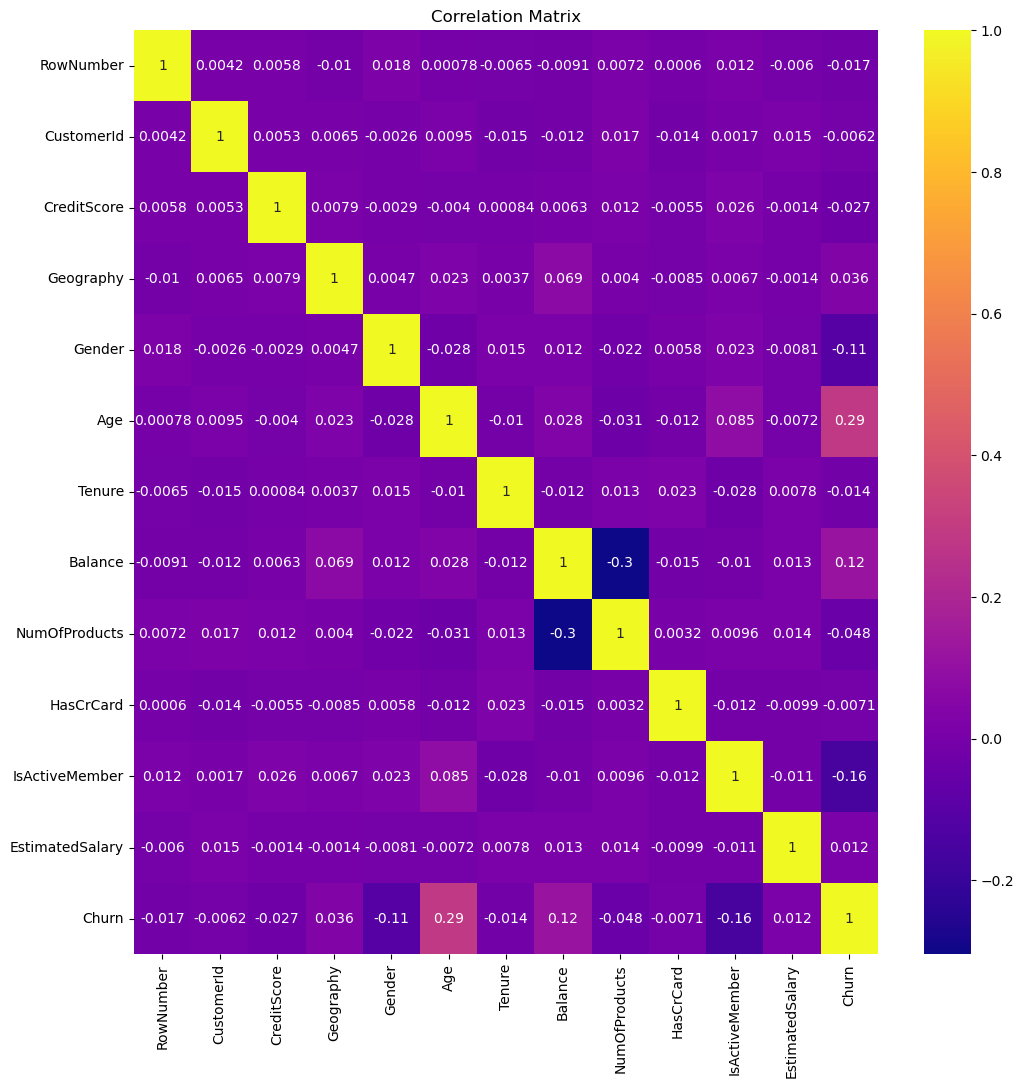

In [34]:
plt.figure(figsize=(12,12))
sns.heatmap(df.select_dtypes(include=['number']).corr(),annot=True,cmap='plasma')
plt.title('Correlation Matrix')
plt.show()

In [35]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop('Churn',axis=1),df['Churn'])

In [36]:
df = df.drop(['RowNumber','CustomerId'], axis=1)

In [37]:
df.head()

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
0,Hargrave,-0.326221,0,0,42,2,-1.225848,1,1,1,0.021886,1
1,Hill,-0.440036,2,0,41,1,0.117350,1,0,1,0.216534,0
2,Onio,-1.536794,0,0,42,8,1.333053,3,1,0,0.240687,1
3,Boni,0.501521,0,0,39,1,-1.225848,2,0,0,-0.108918,0
4,Mitchell,2.063884,2,0,43,2,0.785728,1,1,1,-0.365276,0


In [65]:
# Import the DecisionTreeClassifier from scikit-learn
from sklearn.tree import DecisionTreeClassifier

# Now create the decision tree classifier
dtree = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
dtree


DecisionTreeClassifier(max_depth=4, random_state=42)

In [66]:
dtree.fit(X_train,y_train)
#training accuracy
dtree.score(X_train,y_train)

0.8142857142857143

In [67]:
 dtree_pred = dtree.predict(X_test)

In [71]:
# Import the RandomForestClassifier from scikit-learn
from sklearn.ensemble import RandomForestClassifier

# Now we can create the classifier instance
rfc = RandomForestClassifier(min_samples_leaf=6, max_depth=5, random_state=32)
rfc

RandomForestClassifier(max_depth=5, min_samples_leaf=6, random_state=32)

In [72]:
rfc.fit(X_train, y_train)
#model accuracy
rfc.score(X_train, y_train)

0.7857142857142857

In [73]:
rfc_pred = rfc.predict(X_test)

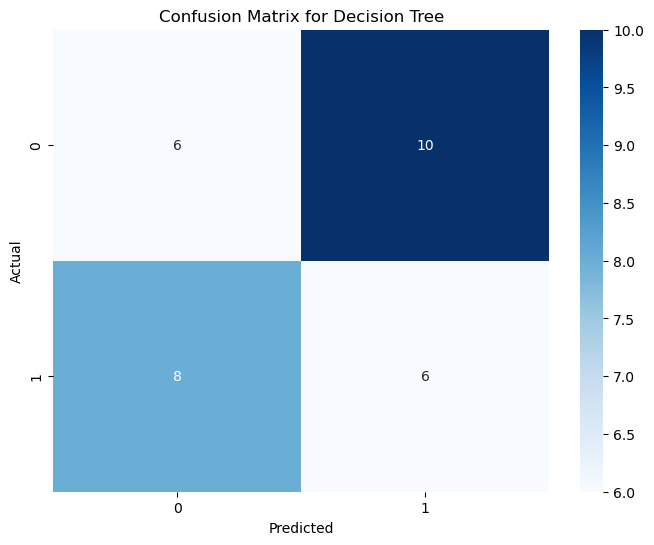

In [74]:
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test,dtree_pred),annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Decision Tree')
plt.show()

C:\Users\devan\AppData\Local\Temp\ipykernel_14928\691906832.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(y_test, hist=False, color="r", label="Actual Value")
C:\Users\devan\AppData\Local\Temp\ipykernel_14928\691906832.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distp

<Axes: ylabel='Density'>

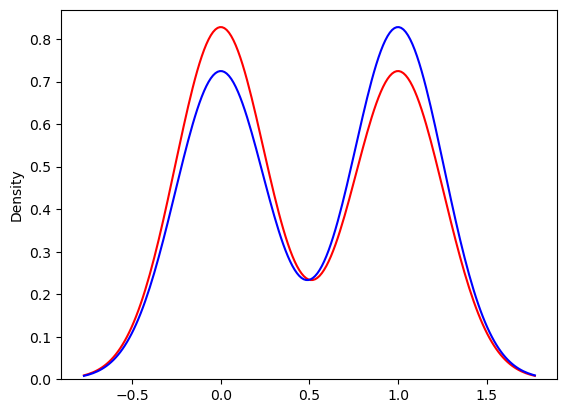

In [75]:
 ax = sns.distplot(y_test, hist=False, color="r", label="Actual Value")
sns.distplot(dtree_pred, hist=False, color="b", label="Fitted Values" , ax=ax)

In [76]:
 from sklearn.metrics import classification_report
print(classification_report(y_test, dtree_pred))

              precision    recall  f1-score   support

           0       0.43      0.38      0.40        16
           1       0.38      0.43      0.40        14

    accuracy                           0.40        30
   macro avg       0.40      0.40      0.40        30
weighted avg       0.40      0.40      0.40        30



In [77]:

from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score
print("Accuracy Score: ", accuracy_score(y_test, dtree_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test, dtree_pred))
print("R2 Score: ", r2_score(y_test, dtree_pred))

Accuracy Score:  0.4
Mean Absolute Error:  0.6
R2 Score:  -1.4107142857142856
